In [11]:
import duckdb
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import os

# ==========================================
# 1. CONEXIÓN Y CREACIÓN DE LA FEATURE MATRIX
# ==========================================
# Cambia esta ruta si tu archivo está en otra carpeta
ruta_db = "../data/BaseDeDatos_Working.db" 

if not os.path.exists(ruta_db):
    raise FileNotFoundError(f"¡Atención! No se encontró el archivo en: {ruta_db}")

con = duckdb.connect(ruta_db)
print("1. Extrayendo datos y construyendo la matriz general...")

# Esta consulta cruza el clima, la demografía y los daños (nuestro Target)
query_maestra = """
WITH clima_pivot AS (
    -- Resumimos los 10 días de clima en un promedio por incendio
    PIVOT (SELECT id_clave_inc, id_variable, resultado_numerico FROM climatologia)
    ON id_variable USING AVG(resultado_numerico) GROUP BY id_clave_inc
),
poblacion_fix AS (
    -- Agrupamos la población por municipio y año
    SELECT id_cvegeo, anio, SUM(pob_total) as pob_total
    FROM demografia 
    GROUP BY id_cvegeo, anio
)
SELECT 
    i.id_clave_inc,
    -- CREAMOS EL TARGET: Suma de todas las hectáreas afectadas
    (COALESCE(d.hojarasca, 0) + COALESCE(d.arbustivo, 0) + 
     COALESCE(d.herbaceo, 0) + COALESCE(d.arbolado_adulto, 0) + 
     COALESCE(d.renuevo, 0)) as superficie_total,
    p.pob_total,
    c.* EXCLUDE (id_clave_inc)
FROM incendios i
JOIN danos d ON i.id_clave_inc = d.id_clave_inc
JOIN poblacion_fix p ON i.id_cvegeo = p.id_cvegeo AND i.anio = p.anio
JOIN clima_pivot c ON i.id_clave_inc = c.id_clave_inc
WHERE (d.hojarasca + d.arbustivo + d.herbaceo + d.arbolado_adulto + d.renuevo) IS NOT NULL;
"""

df_completo = con.execute(query_maestra).df()

# Filtramos SOLO columnas numéricas y rellenamos nulos con 0 para evitar errores matemáticos
df_num = df_completo.select_dtypes(include=[np.number]).fillna(0)
print(f"Matriz lista. Analizando {df_num.shape[0]} incendios con {df_num.shape[1]} variables.")

# ==========================================
# 2. GRÁFICA 1: LA MATRIZ SUCIA (El Caos)
# ==========================================
print("\n2. Generando Matriz Sucia (Todas las variables amontonadas)...")

corr_sucia = df_num.corr()

fig_sucia = go.Figure(data=go.Heatmap(
    z=corr_sucia.values,
    x=corr_sucia.columns,
    y=corr_sucia.columns,
    colorscale='YlOrRd', # Colores cálidos para ver el "fuego" de la redundancia
    zmin=0, zmax=1,
    hovertemplate="Var 1: %{x}<br>Var 2: %{y}<br>Similitud: %{z:.3f}<extra></extra>"
))

fig_sucia.update_layout(
    title='MATRIZ SUCIA: Redundancia en 120+ Variables (NASA + INEGI + CONAFOR)',
    width=1000, height=1000,
    xaxis=dict(tickfont=dict(size=8)), 
    yaxis=dict(tickfont=dict(size=8))
)
fig_sucia.show()

# ==========================================
# 3. FILTRO CIENTÍFICO (Eliminando ruido)
# ==========================================
print("\n3. Aplicando filtro inteligente: Seleccionando líderes por capacidad predictiva...")

# Calculamos qué variable explica mejor las hectáreas quemadas
influencia = df_num.corr()['superficie_total'].abs().sort_values(ascending=False)

def limpiar_redundancia(df_input, target_corr, umbral=0.95):
    matriz = df_input.corr().abs()
    triangulo_sup = matriz.where(np.triu(np.ones(matriz.shape), k=1).astype(bool))
    
    borrar = []
    for col in triangulo_sup.columns:
        if col == 'superficie_total': continue # Jamás borramos nuestra meta
        
        # Encontramos los clones
        clones = triangulo_sup.index[triangulo_sup[col] > umbral].tolist()
        if clones:
            grupo = [col] + clones
            # De los clones, gana el que tenga mayor correlación con 'superficie_total'
            ganadora = target_corr[grupo].idxmax()
            perdedoras = [v for v in grupo if v != ganadora]
            borrar.extend(perdedoras)
            
    return list(set(borrar))

vars_a_borrar = limpiar_redundancia(df_num, influencia)
df_limpio = df_num.drop(columns=vars_a_borrar)

print(f"Se eliminaron {len(vars_a_borrar)} variables redundantes.")
print(f"Nos quedamos con {len(df_limpio.columns) - 1} variables 100% independientes.")

# ==========================================
# 4. GRÁFICA 2: LA MATRIZ LIMPIA (Lista para Machine Learning)
# ==========================================
print("\n4. Generando Matriz Limpia...")

corr_limpia = df_limpio.corr()

fig_limpia = go.Figure(data=go.Heatmap(
    z=corr_limpia.values,
    x=corr_limpia.columns,
    y=corr_limpia.columns,
    colorscale='RdBu_r', # Azul es influencia negativa, Rojo es influencia positiva
    zmin=-1, zmax=1,
    hovertemplate="Var 1: %{x}<br>Var 2: %{y}<br>Correlación: %{z:.3f}<extra></extra>"
))

fig_limpia.update_layout(
    title='MATRIZ LIMPIA: Variables Independientes listas para Modelo Predictivo',
    width=900, height=900,
    xaxis=dict(tickfont=dict(size=10)), 
    yaxis=dict(tickfont=dict(size=10))
)
fig_limpia.show()

# ==========================================
# 5. EL VEREDICTO: TOP 10 INFLUENCIAS
# ==========================================
print("\n=======================================================")
print("🏆 TOP 10: VARIABLES QUE MÁS INFLUYEN EN EL TAMAÑO DEL INCENDIO 🏆")
print("=======================================================")
# Quitamos el target de la lista para mostrar solo los predictores
ranking = influencia[df_limpio.columns].sort_values(ascending=False).drop('superficie_total')
print(ranking.head(10))

1. Extrayendo datos y construyendo la matriz general...
Matriz lista. Analizando 12586 incendios con 124 variables.

2. Generando Matriz Sucia (Todas las variables amontonadas)...



3. Aplicando filtro inteligente: Seleccionando líderes por capacidad predictiva...
Se eliminaron 65 variables redundantes.
Nos quedamos con 58 variables 100% independientes.

4. Generando Matriz Limpia...



🏆 TOP 10: VARIABLES QUE MÁS INFLUYEN EN EL TAMAÑO DEL INCENDIO 🏆
CDD18_3        0.150671
TSOIL4         0.107278
T2M_MIN        0.107199
GWETTOP        0.084298
TS_ADJ         0.082813
EVLAND         0.075619
CLOUD_OD       0.073891
RH2M           0.072555
WS50M_RANGE    0.071277
EVPTRNS        0.068016
Name: superficie_total, dtype: float64


In [12]:
# 1. Identificamos las variables de vegetación (que suelen empezar con ND o traer VEG)
# En el dataset de la NASA suelen ser NDVI, NDMI, etc.
vars_vegetacion = [c for c in df_num.columns if 'ND' in c or 'VEG' in c]

print("--- 📊 Influencia de la Vegetación contra el Daño ---")
if vars_vegetacion:
    # Mostramos su correlación con la superficie quemada
    print(target_corr[vars_vegetacion])
    
    # 2. Verificamos si fueron eliminadas por ser 'clones' de alguna climática
    # Aquí usamos el nombre correcto: 'vars_a_borrar'
    eliminadas_veg = [v for v in vars_vegetacion if v in vars_a_borrar]
    
    print(f"\n🚫 Variables de vegetación descartadas por redundancia: {eliminadas_veg}")
    
    # 3. Tip para saber contra quién perdieron
    if eliminadas_veg:
        print("\n💡 Nota: Si fueron eliminadas, es porque una variable climática (como humedad o temperatura)")
        print("explicaba mejor el incendio y tenía una correlación > 95% con ellas.")
else:
    print("No se encontraron variables con 'ND' o 'VEG' en el DataFrame numérico.")

--- 📊 Influencia de la Vegetación contra el Daño ---


NameError: name 'target_corr' is not defined

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

# ==========================================
# 1. PREPARACIÓN DE DATOS (+ ESTACIONALIDAD)
# ==========================================
print("1. Extrayendo variables, régimen de fuego y MES del año...")

df_limpio['id_clave_inc'] = df_completo['id_clave_inc']

# MODIFICACIÓN: Ahora también extraemos el mes de la fecha de inicio
query_extras = """
SELECT 
    i.id_clave_inc, 
    v.regimen_del_fuego,
    EXTRACT(MONTH FROM i.fecha_inicio) as mes_incendio
FROM incendios i
JOIN vegetacion v ON i.id_vegetacion = v.id_vegetacion
"""
df_extras = con.execute(query_extras).df()

# Convertimos el mes a texto (string) para que el modelo no crea que "Diciembre (12)" 
# vale el doble que "Junio (6)". Son categorías, no cantidades.
df_extras['mes_incendio'] = df_extras['mes_incendio'].astype(str)

# Unimos todo
df_ml = df_limpio.merge(df_extras, on='id_clave_inc', how='inner')

# Convertimos texto a columnas numéricas (Tanto el régimen como los meses)
df_ml = pd.get_dummies(df_ml, columns=['regimen_del_fuego', 'mes_incendio'], drop_first=True)

# Separamos X y Y
X = df_ml.drop(columns=['id_clave_inc', 'superficie_total'])
y = df_ml['superficie_total']

print(f"Matriz lista: {X.shape[0]} incendios y {X.shape[1]} variables predictoras.")

# ==========================================
# 2. TRANSFORMACIÓN LOGARÍTMICA
# ==========================================
print("\n2. Aplicando compresión logarítmica a las hectáreas...")
y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 3. ENTRENAMIENTO ROBUSTO
# ==========================================
print("\n3. Entrenando Random Forest de Vulnerabilidad...")
modelo = RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42)
modelo.fit(X_train_scaled, y_train_log)

# ==========================================
# 4. EVALUACIÓN 
# ==========================================
preds_log = modelo.predict(X_test_scaled)
preds_reales = np.expm1(preds_log)
y_test_real = np.expm1(y_test_log)

print(f"\n--- MÉTRICAS DEL MODELO ---")
print(f"R2 Score: {r2_score(y_test_log, preds_log):.4f}")
print(f"Margen de error promedio (MAE): {mean_absolute_error(y_test_real, preds_reales):.2f} hectáreas")

# ==========================================
# 5. EL RANKING DEFINITIVO
# ==========================================
importancias = pd.Series(modelo.feature_importances_, index=X.columns)

print("\n=======================================================")
print("🏆 TOP 15: VARIABLES CON ESTACIONALIDAD 🏆")
print("=======================================================")
print(importancias.sort_values(ascending=False).head(15))

1. Extrayendo variables, régimen de fuego y MES del año...
Matriz lista: 12586 incendios y 71 variables predictoras.

2. Aplicando compresión logarítmica a las hectáreas...

3. Entrenando Random Forest de Vulnerabilidad...

--- MÉTRICAS DEL MODELO ---
R2 Score: 0.1885
Margen de error promedio (MAE): 8.97 hectáreas

🏆 TOP 15: VARIABLES CON ESTACIONALIDAD 🏆
pob_total                        0.093774
regimen_del_fuego_dependiente    0.057956
NDWI                             0.052875
TSOIL4                           0.040990
EVPTRNS                          0.038389
NDVI                             0.035170
NDMI                             0.033718
WS50M_RANGE                      0.025574
CDD18_3                          0.025037
RH2M                             0.024187
TS_ADJ                           0.022683
DISPH                            0.022315
CLOUD_OD                         0.022082
PBLTOP                           0.019972
TROPPB                           0.019804
dtype: float

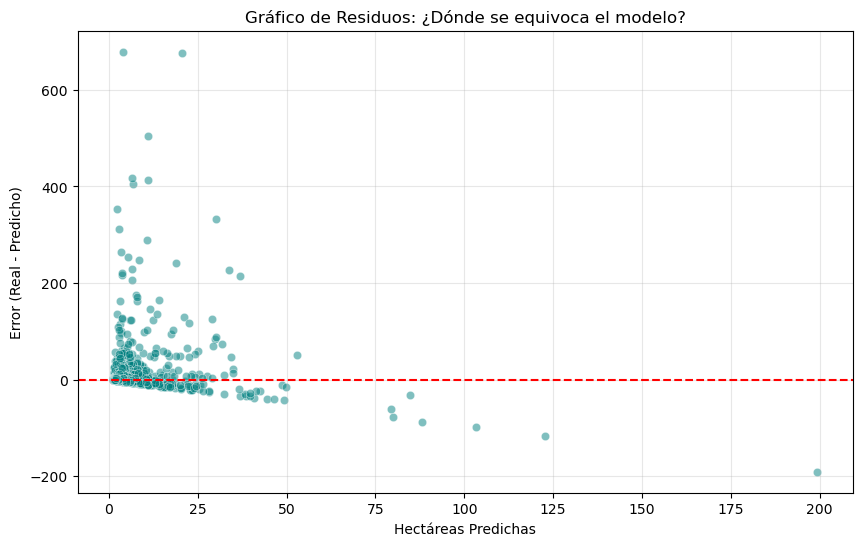


🚑 AUTOPSIA: LOS 10 INCENDIOS CON MAYOR ERROR
             Real   Predicho  Error_Absoluto  pob_total      NDWI      NDVI
3592   683.040100   4.009589      679.030511    71381.0  0.227497  0.455105
12246  696.210022  20.662261      675.547761     7412.0  0.015805  0.551119
3204   516.000122  11.091356      504.908766    25119.0  0.271680  0.678209
9840   424.000000   6.524182      417.475818   285111.0  0.048616  0.496680
6558   425.000092  11.017371      413.982721    54364.0  0.069519  0.544004
4047   412.179993   6.705003      405.474990    13344.0 -0.182529  0.338041
9630   356.172943   2.206666      353.966277    53469.0  0.099775  0.447024
6058   362.000061  30.231145      331.768916     9844.0 -0.059986  0.517084
3546   314.999939   2.774985      312.224954    49905.0  0.161557  0.628997
9698   300.000031  10.608053      289.391977     9900.0 -0.160115  0.339275


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculamos los errores (Residuos)
# Usamos los valores reales (hectáreas) para que el análisis sea humano y entendible
residuos = y_test_real - preds_reales

# 2. Creamos un DataFrame de diagnóstico para analizar los peores errores
df_diagnostico = X_test.copy()
df_diagnostico['Real'] = y_test_real
df_diagnostico['Predicho'] = preds_reales
df_diagnostico['Error_Absoluto'] = abs(residuos)
df_diagnostico['Residuo'] = residuos

# ==========================================
# 3. VISUALIZACIÓN 1: GRÁFICO DE RESIDUOS
# ==========================================
plt.figure(figsize=(10, 6))
sns.scatterplot(x=preds_reales, y=residuos, alpha=0.5, color='teal')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Gráfico de Residuos: ¿Dónde se equivoca el modelo?')
plt.xlabel('Hectáreas Predichas')
plt.ylabel('Error (Real - Predicho)')
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# 4. IDENTIFICACIÓN DE LOS 10 PEORES ERRORES
# ==========================================
print("\n" + "="*60)
print("🚑 AUTOPSIA: LOS 10 INCENDIOS CON MAYOR ERROR")
print("="*60)
# Ordenamos por los errores más grandes
peores_errores = df_diagnostico.sort_values(by='Error_Absoluto', ascending=False).head(10)

# Mostramos columnas clave para entender por qué falló
# (Ajustamos los nombres de las columnas según tu Top 15)
columnas_analisis = ['Real', 'Predicho', 'Error_Absoluto', 'pob_total', 'NDWI', 'NDVI']
print(peores_errores[columnas_analisis])

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# ==========================================
# 1. CÁLCULO DE PESOS (LA ESTRATEGIA)
# ==========================================
print("1. Calculando pesos de importancia para el entrenamiento...")

# Definimos el peso: incendios más grandes = más importancia
# Usamos sqrt(y) para que el peso sea significativo pero no extremo
pesos = np.sqrt(df_ml['superficie_total']) + 1

# ==========================================
# 2. PREPARACIÓN DE DATOS
# ==========================================
y_log = np.log1p(df_ml['superficie_total'])
X = df_ml.drop(columns=['id_clave_inc', 'superficie_total'])

# Dividimos datos y PESOS simultáneamente
X_train, X_test, y_train_log, y_test_log, weights_train, weights_test = train_test_split(
    X, y_log, pesos, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 3. ENTRENAMIENTO CON PESOS
# ==========================================
print("2. Entrenando Modelo con Pesado de Muestra...")

modelo_pesado = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)

# PASO CLAVE: Aquí le pasamos los pesos al entrenamiento
modelo_pesado.fit(X_train_scaled, y_train_log, sample_weight=weights_train)

# ==========================================
# 4. EVALUACIÓN Y NUEVO TOP 15
# ==========================================
preds_log = modelo_pesado.predict(X_test_scaled)
preds_reales = np.expm1(preds_log)
y_test_real = np.expm1(y_test_log)

print(f"\n--- MÉTRICAS DEL MODELO PESADO ---")
print(f"R2 Score (en escala log): {r2_score(y_test_log, preds_log):.4f}")
print(f"Nuevo MAE: {mean_absolute_error(y_test_real, preds_reales):.2f} hectáreas")

importancias = pd.Series(modelo_pesado.feature_importances_, index=X.columns)
print("\n=======================================================")
print("🏆 TOP 15: VARIABLES DEFINITIVAS (CON PESO) 🏆")
print("=======================================================")
print(importancias.sort_values(ascending=False).head(15))

1. Calculando pesos de importancia para el entrenamiento...
2. Entrenando Modelo con Pesado de Muestra...

--- MÉTRICAS DEL MODELO PESADO ---
R2 Score (en escala log): 0.1795
Nuevo MAE: 9.05 hectáreas

🏆 TOP 15: VARIABLES DEFINITIVAS (CON PESO) 🏆
regimen_del_fuego_dependiente    0.080989
pob_total                        0.074856
TSOIL4                           0.064005
NDWI                             0.045284
EVPTRNS                          0.042173
TS_ADJ                           0.034173
CLRSKY_SFC_LW_UP                 0.031778
GWETTOP                          0.028635
CDD18_3                          0.026838
WS50M_RANGE                      0.026752
NDVI                             0.024924
NDMI                             0.022949
TROPPB                           0.022237
PBLTOP                           0.022204
CLOUD_OD                         0.021324
dtype: float64


In [14]:
# Uniendo los 4 niveles de tu esquema SQL en un solo DataFrame Maestro
query_maestra_total = """
SELECT 
    i.id_clave_inc,
    -- Capa 1: Vegetación y Causa (Biología y Origen)
    v.regimen_del_fuego,
    c_causa.causa as causa_general,
    
    -- Capa 2 y 3: Geografía y Tiempo
    m.nombre_municipio,
    EXTRACT(MONTH FROM i.fecha_inicio) as mes,
    
    -- Capa 3.5: Demografía (Sociedad)
    p.pob_total,
    
    -- Capa 4: Daños (Nuestra meta a predecir)
    (d.hojarasca + d.arbustivo + d.herbaceo + d.arbolado_adulto + d.renuevo) as superficie_total,
    
    -- Capa Especial: Climatología (Las 58 variables ganadoras ya filtradas)
    clima.* EXCLUDE (id_clave_inc)

FROM incendios i
JOIN municipios m ON i.id_cvegeo = m.id_cvegeo
JOIN estado e ON m.id_clave_ent = e.id_clave_ent
JOIN vegetacion v ON i.id_vegetacion = v.id_vegetacion
JOIN causa c_causa ON i.id_causa = c_causa.id_causa
JOIN danos d ON i.id_clave_inc = d.id_clave_inc
JOIN demografia p ON i.id_cvegeo = p.id_cvegeo AND i.anio = p.anio
JOIN (
    PIVOT (SELECT id_clave_inc, id_variable, resultado_numerico FROM climatologia)
    ON id_variable USING AVG(resultado_numerico) GROUP BY id_clave_inc
) clima ON i.id_clave_inc = clima.id_clave_inc

WHERE e.id_clave_ent = 15 -- FILTRO ESTRICTO: SOLO EDOMEX
AND superficie_total > 0;
"""

df_maestro = con.execute(query_maestra_total).df()
print(f"¡Logrado! Matriz integrada con {df_maestro.shape[1]} columnas de conocimiento puro.")

¡Logrado! Matriz integrada con 129 columnas de conocimiento puro.


In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

# ==========================================
# 1. LIMPIEZA FINAL Y CATEGORÍAS
# ==========================================
print("1. Procesando 129 variables...")

# Eliminamos los IDs y nombres que no son matemáticos
X = df_maestro.drop(columns=['id_clave_inc', 'nombre_municipio', 'superficie_total'])
y = df_maestro['superficie_total']

# Convertimos las variables de texto (Causa, Régimen, Mes) a números (0 y 1)
X = pd.get_dummies(X, columns=['regimen_del_fuego', 'causa_general', 'mes'], drop_first=True)

# Pesos: Incendios > 50ha valen 5 veces más para el modelo
pesos = df_maestro['superficie_total'].apply(lambda x: 5.0 if x > 50 else 1.0)

# ==========================================
# 2. TRANSFORMACIÓN Y DIVISIÓN
# ==========================================
y_log = np.log1p(y) # Aplicamos el logaritmo para estabilizar el target

X_train, X_test, y_train_log, y_test_log, w_train, w_test = train_test_split(
    X, y_log, pesos, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 3. EL ENTRENAMIENTO DEFINITIVO
# ==========================================
print(f"2. Entrenando con {X.shape[1]} predictores finales...")

# n_estimators=300 porque con 129 variables necesitamos más 'opiniones' dentro del bosque
modelo_final = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42)
modelo_final.fit(X_train_scaled, y_train_log, sample_weight=w_train)

# ==========================================
# 4. MÉTRICAS DE CERTEZA
# ==========================================
preds_log = modelo_final.predict(X_test_scaled)
preds_reales = np.expm1(preds_log)
y_test_real = np.expm1(y_test_log)

print(f"\n--- RESULTADOS DEL MODELO INTEGRADO ---")
print(f"R2 Score (Capacidad predictiva): {r2_score(y_test_log, preds_log):.4f}")
print(f"Error MAE: {mean_absolute_error(y_test_real, preds_reales):.2f} hectáreas")

# ==========================================
# 5. EL RANKING DE LAS 129 VARIABLES
# ==========================================
importancias = pd.Series(modelo_final.feature_importances_, index=X.columns)
print("\n🏆 LAS 15 VARIABLES QUE REALMENTE MANDAN EN EDOMEX 🏆")
print(importancias.sort_values(ascending=False).head(15))

1. Procesando 129 variables...
2. Entrenando con 153 predictores finales...

--- RESULTADOS DEL MODELO INTEGRADO ---
R2 Score (Capacidad predictiva): 0.5794
Error MAE: 9.61 hectáreas

🏆 LAS 15 VARIABLES QUE REALMENTE MANDAN EN EDOMEX 🏆
TSOIL6                           0.135153
pob_total                        0.074152
EVPTRNS                          0.070800
NDWI                             0.040490
regimen_del_fuego_dependiente    0.034805
NDVI                             0.024765
NDMI                             0.023934
RH2M                             0.019290
WS50M_RANGE                      0.015391
U50M                             0.014677
PS                               0.012784
CLOUD_OD                         0.011959
TO3                              0.011949
V2M                              0.011042
V50M                             0.009751
dtype: float64


In [16]:
import plotly.express as px

# 1. Recuperamos coordenadas asegurando que NO sean nulas
ids_test = df_maestro.iloc[X_test.index]['id_clave_inc'].tolist()

# Filtramos directamente en SQL para traer solo lo que tiene ubicación
query_coords = f"""
    SELECT id_clave_inc, latitud, longitud 
    FROM incendios 
    WHERE id_clave_inc IN {tuple(ids_test)}
    AND latitud IS NOT NULL 
    AND longitud IS NOT NULL
"""
df_coords = con.execute(query_coords).df()

# 2. Unimos con tus predicciones
df_mapa = pd.DataFrame({
    'id_clave_inc': ids_test,
    'Hectáreas_Predichas': preds_reales,
    'Hectáreas_Reales': y_test_real
})
df_mapa = df_mapa.merge(df_coords, on='id_clave_inc')

fig = px.density_mapbox(
    df_mapa, 
    lat='latitud', 
    lon='longitud', 
    z='Hectáreas_Predichas', 
    radius=20, 
    center=dict(lat=19.35, lon=-99.6), 
    zoom=8,
    # CAMBIA ESTA LÍNEA:
    mapbox_style="carto-positron", # Este no te va a bloquear
    title='MAPA DE VULNERABILIDAD PREDICHA (EDOMEX)',
    labels={'Hectáreas_Predichas': 'Potencial de Daño (ha)'},
    hover_data={'Hectáreas_Reales': True, 'Hectáreas_Predichas': ':.2f'},
    color_continuous_scale="YlOrRd"
)

fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})

# Si estás en VS Code o Jupyter, esto ayuda a forzar la aparición
fig.show()

In [17]:
# Buscamos los IDs de tu tabla en los resultados del test
ids_interes = ['23-15-0791', '25-15-0443', '24-15-0324'] # Sultepec, Ocuilan, Amecameca
comparativa_real = df_mapa[df_mapa['id_clave_inc'].isin(ids_interes)]

print("🔍 COMPARATIVA DIRECTA: MODELO VS REALIDAD")
print(comparativa_real[['id_clave_inc', 'Hectáreas_Reales', 'Hectáreas_Predichas']])

🔍 COMPARATIVA DIRECTA: MODELO VS REALIDAD
    id_clave_inc  Hectáreas_Reales  Hectáreas_Predichas
645   24-15-0324       1546.019897           286.898822
